PART A

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

print("Gowtham S - 24BAD028")
# Set random seed for reproducibility
np.random.seed(42)


# 1. Load Tiny Shakespeare Dataset from Source URL

print("Loading Tiny Shakespeare dataset...")

# Loading directly from the source to avoid deprecated dataset scripts
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
with urllib.request.urlopen(url) as f:
    text = f.read().decode('utf-8')

print("\nDataset loaded successfully!")
print(f"Total characters in source: {len(text)}")

# 2. Explore Dataset
print("\nFirst 500 characters of the dataset:\n")
print(text[:500])


# 3. Convert Text to Lowercase

text = text.lower()


# 4. Tokenize Text into Words

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("\nVocabulary Size:", total_words)

# Convert complete text into word sequence
word_sequence = tokenizer.texts_to_sequences([text])[0]

print("\nFirst 20 word indices:")
print(word_sequence[:20])


# 5. Generate Input Sequences for Next-Word Prediction

sequence_length = 10

input_sequences = []

for i in range(sequence_length, len(word_sequence)):
    sequence = word_sequence[i-sequence_length:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("\nInput Sequences Shape:", input_sequences.shape)


# 6. Separate Input and Output

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("\nInput X Shape:", X.shape)
print("Output y Shape:", y.shape)


# 7. Apply Padding

X = pad_sequences(
    X,
    maxlen=sequence_length,
    padding="pre"
)

print("\nPadded Input Shape:", X.shape)


# 8. Split into Training and Validation Data

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)

print("\nPART A COMPLETED SUCCESSFULLY")

Gowtham S - 24BAD028
Loading Tiny Shakespeare dataset...

Dataset loaded successfully!
Total characters in source: 1115394

First 500 characters of the dataset:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Vocabulary Size: 12634

First 20 word indices:
[89, 270, 140, 36, 970, 144, 669, 128, 16, 103, 34, 103, 103, 89, 270, 7, 41, 34, 1269, 351]

Input Sequences Shape: (204079, 11)

Input X Shape: (204079, 10)
Output y Shape: (204079,)

Padded Input Shape: (204079, 10)

Training Data Shape: (163263, 10)
Validation Data Shape: (40816, 10)


PART B


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Create RNN Model

model = Sequential([
    
    # Embedding Layer
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=sequence_length
    ),
    
    # Simple RNN Layer
    SimpleRNN(
        128,
        activation="tanh"
    ),
    
    # Output Layer
    Dense(
        total_words,
        activation="softmax"
    )
])

# Compile Model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Build and Display Model Architecture

model.build(input_shape=(None, sequence_length))

print("MODEL SUMMARY\n")

model.summary()

print("\nPART B COMPLETED SUCCESSFULLY")


c:\Users\HP\anaconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 64)         │       808,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12634)          │     1,629,786 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,463,066 (9.40 MB)

 Trainable params: 2,463,066 (9.40 MB)

 Non-trainable params: 0 (0.00 B)


PART B COMPLETED SUCCESSFULLY


PART C

Epoch 1/3
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 73s 56ms/step - accuracy: 0.0448 - loss: 6.7629 - val_accuracy: 0.0687 - val_loss: 6.4271
Epoch 2/3
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 74s 58ms/step - accuracy: 0.0785 - loss: 6.1248 - val_accuracy: 0.0824 - val_loss: 6.3125
Epoch 3/3
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 55s 43ms/step - accuracy: 0.0923 - loss: 5.8074 - val_accuracy: 0.0865 - val_loss: 6.3216

FINAL PERFORMANCE

Training Accuracy: 0.09226217865943909
Validation Accuracy: 0.08651018887758255
Training Loss: 5.80744743347168
Validation Loss: 6.321643352508545


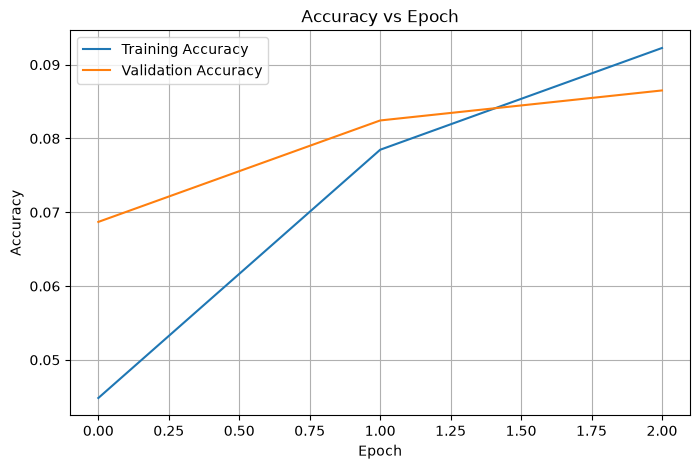

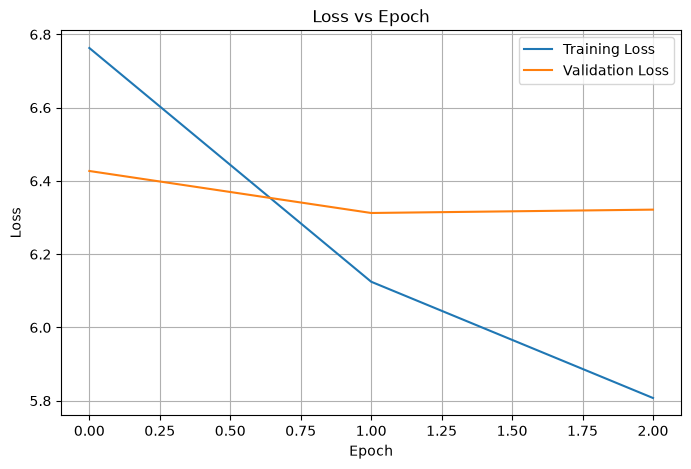


PART C COMPLETED SUCCESSFULLY


In [ ]:

# Train the RNN Model

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)


# Final Training and Validation Results

print("\nFINAL PERFORMANCE\n")

print("Training Accuracy:",
      history.history["accuracy"][-1])

print("Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Training Loss:",
      history.history["loss"][-1])

print("Validation Loss:",
      history.history["val_loss"][-1])


# Accuracy vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()


# Loss vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

print("\nPART C COMPLETED SUCCESSFULLY")

PART D

In [ ]:
def generate_text(seed_text, next_words=20):
    
    generated_text = seed_text.lower()
    
    for _ in range(next_words):
        
        # Convert text into sequence
        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]
        
        # Keep only the last sequence_length words
        token_list = token_list[-sequence_length:]
        
        # Apply padding
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )
        
        # Predict next word
        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )
        
        predicted_index = np.argmax(
            predicted_probabilities
        )
        
        # Convert predicted index back to word
        predicted_word = tokenizer.index_word.get(
            predicted_index,
            ""
        )
        
        # Add predicted word
        generated_text += " " + predicted_word
    
    return generated_text



# Generate Text using Different Seed Inputs

seed_1 = "to be or not"
seed_2 = "the king"
seed_3 = "i will"

print("TEXT GENERATION RESULTS\n")

print("Seed Text 1:")
print(seed_1)

print("\nGenerated Text:")
print(generate_text(seed_1, next_words=20))


print("\n" + "="*70)

print("\nSeed Text 2:")
print(seed_2)

print("\nGenerated Text:")
print(generate_text(seed_2, next_words=20))


print("\n" + "="*70)

print("\nSeed Text 3:")
print(seed_3)

print("\nGenerated Text:")
print(generate_text(seed_3, next_words=20))


print("\nPART D COMPLETED SUCCESSFULLY")

TEXT GENERATION RESULTS

Seed Text 1:
to be or not

Generated Text:
to be or not a man of the king of york and i have not to the king of york and i have not


Seed Text 2:
the king

Generated Text:
the king of york and i have not to the king of york and i have not to the king of york


Seed Text 3:
i will

Generated Text:
i will not to the king of york and i have not to the king of york and i have not to

PART D COMPLETED SUCCESSFULLY
